# AfterMath — Grad-CAM

Explainability: which parts of the before/after images drove each prediction.

In [1]:
import sys
sys.path.insert(0, '..')  # so `utils` (repo root) is importable when cwd is notebooks/

import yaml
import pandas as pd
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from utils.model import SiameseDamageNet
from utils.gradcam import GradCAM, resize_cam
from utils.transforms import build_eval_transform
from utils.xbd_labels import DAMAGE_CLASSES

config = yaml.safe_load(open('../config.yaml'))
device = torch.device('cpu')  # Grad-CAM run on CPU for simplicity

model = SiameseDamageNet(num_classes=config['model']['num_classes'], pretrained=False).to(device)
model.load_state_dict(torch.load('../models/best.pt', map_location=device))
model.eval()

cam_tool = GradCAM(model, model.backbone.layer4[-1])

In [2]:
test_manifest = pd.read_csv('../data/processed/manifest_test.csv')
transform = build_eval_transform()

def load_tensor(path):
    return transform(Image.open(path).convert('RGB')).unsqueeze(0)

def overlay_heatmap(image, cam):
    cam_resized = resize_cam(cam, size=image.shape[0])
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    return (0.5 * image / 255.0 + 0.5 * heatmap)

## Class-stratified samples

Random sampling from the whole test set would be dominated by `no-damage` / `minor-damage`, since those two classes make up most of the held-out Hurricane Michael test set. To give a full, honest picture of the model's behavior across all four damage classes -- including the classes it struggles with -- we sample **2 examples per damage class** (8 rows total) instead of 3 random rows overall. Each row's title shows both the true label and the model's predicted label, so correct and incorrect predictions are both visible; we do not cherry-pick only correct predictions.

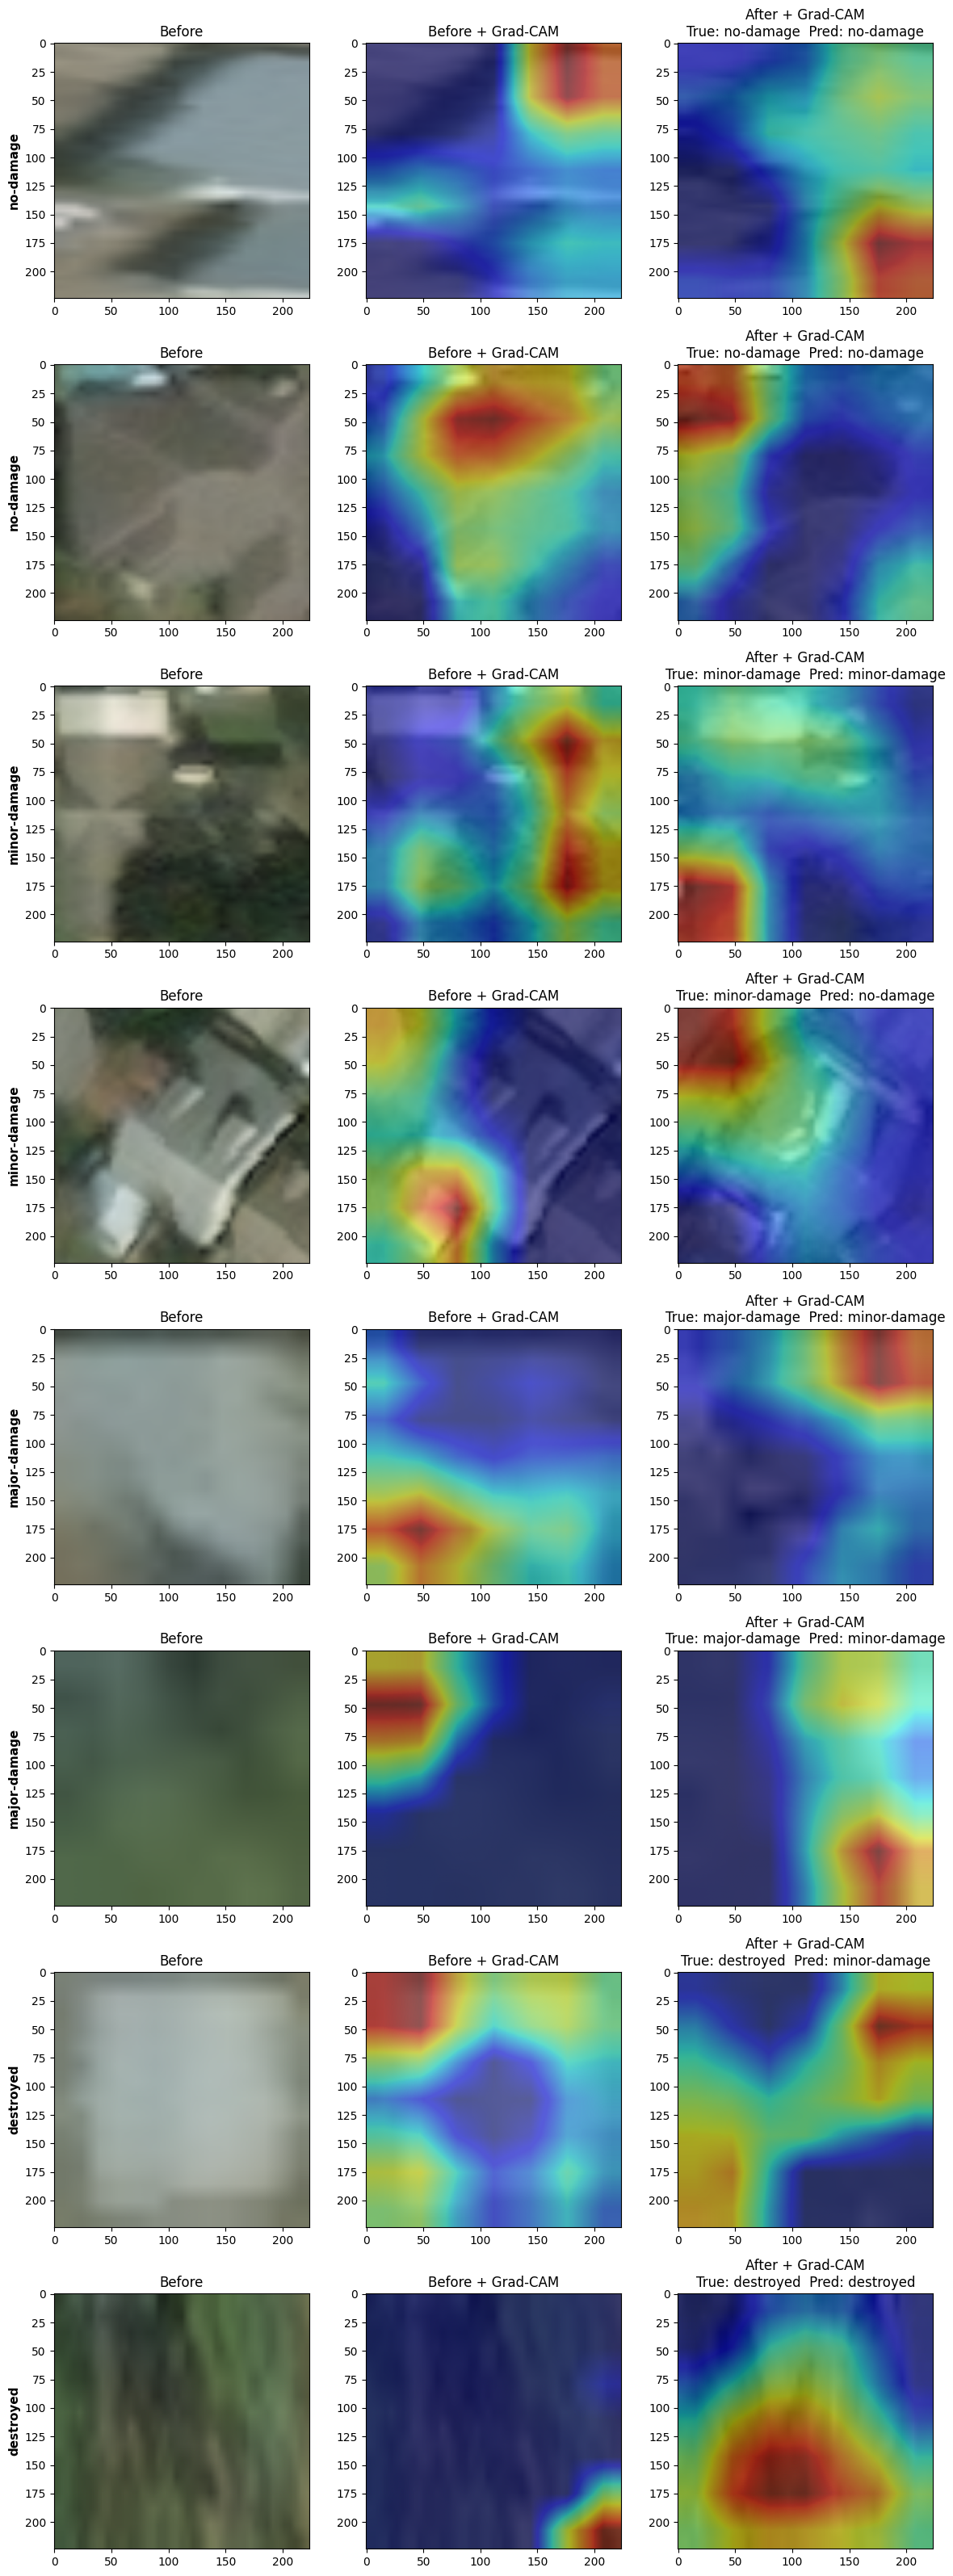

In [3]:
samples = pd.concat(
    [test_manifest[test_manifest['damage_class'] == cls].sample(2, random_state=42) for cls in DAMAGE_CLASSES],
    ignore_index=True,
)

fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4 * len(samples)))
for row_idx, (_, row) in enumerate(samples.iterrows()):
    pre_tensor = load_tensor(row['pre_path'])
    post_tensor = load_tensor(row['post_path'])
    with torch.enable_grad():
        logits = model(pre_tensor, post_tensor)
        pred_class = logits.argmax(dim=1).item()

    pre_cam = cam_tool.generate(pre_tensor, post_tensor, target_class=pred_class, branch='pre')
    post_cam = cam_tool.generate(pre_tensor, post_tensor, target_class=pred_class, branch='post')

    pre_img = np.array(Image.open(row['pre_path']).convert('RGB'))
    post_img = np.array(Image.open(row['post_path']).convert('RGB'))

    axes[row_idx, 0].imshow(pre_img)
    axes[row_idx, 0].set_title('Before')
    axes[row_idx, 0].set_ylabel(row['damage_class'], fontsize=11, fontweight='bold')
    axes[row_idx, 1].imshow(overlay_heatmap(pre_img, pre_cam))
    axes[row_idx, 1].set_title('Before + Grad-CAM')
    axes[row_idx, 2].imshow(overlay_heatmap(post_img, post_cam))
    axes[row_idx, 2].set_title(f'After + Grad-CAM\nTrue: {row["damage_class"]}  Pred: {DAMAGE_CLASSES[pred_class]}')

plt.tight_layout()
plt.savefig('../docs/gradcam_samples.png', dpi=150, bbox_inches='tight')
plt.show()